<a href="https://colab.research.google.com/github/volvox09/Pneumonia-Detection-AI/blob/main/Zaturre_Tespit_Projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os


os.environ['KAGGLE_USERNAME'] = "lkayceylan"
os.environ['KAGGLE_KEY'] = "KGAT_f2ee19bed9dacefd0e23710cd9b7f970"

# Veri setini indir
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Zipten çıkar
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 232MB/s]



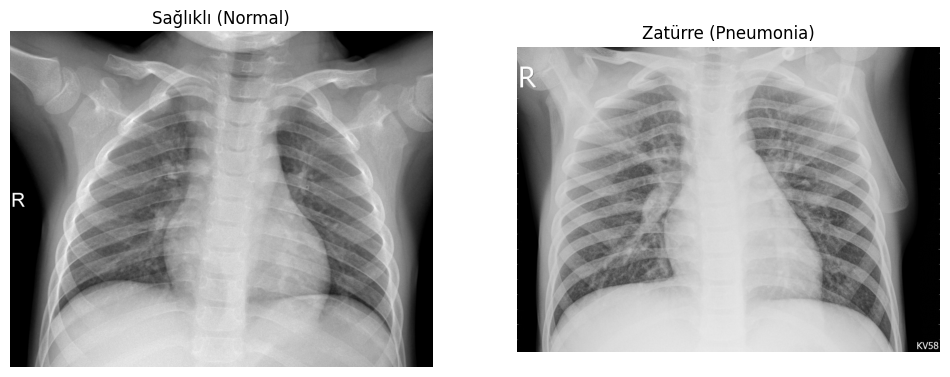

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Rastgele bir normal ve bir zatürre resmi seçelim
normal_path = "/content/chest_xray/train/NORMAL/"
pneumonia_path = "/content/chest_xray/train/PNEUMONIA/"

normal_img = os.listdir(normal_path)[0]
pneumonia_img = os.listdir(pneumonia_path)[0]

# Görselleştirme
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
img1 = mpimg.imread(normal_path + normal_img)
plt.imshow(img1, cmap='gray')
plt.title('Sağlıklı (Normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
img2 = mpimg.imread(pneumonia_path + pneumonia_img)
plt.imshow(img2, cmap='gray')
plt.title('Zatürre (Pneumonia)')
plt.axis('off')

plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# Görüntüleri hazırlamak için gerekli araçları ayarlayalım
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Klasörlerden görüntüleri çekelim
training_set = train_datagen.flow_from_directory(
    '/content/chest_xray/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    '/content/chest_xray/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Modeli oluşturmaya başlıyoruz
model = Sequential()

# 1. Katman: Görüntüdeki özellikleri yakalar
model.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2. Katman: Daha derin özellikleri yakalar
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Katman: Sayısal veriye dönüştürme (Düzleştirme)
model.add(Flatten())

# 4. Katman: Karar verme (Full Connection)
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # Sonuç 0 (Sağlıklı) veya 1 (Zatürre)

# Modeli derleyelim
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Modelin özetine bakalım
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Modeli eğitmeye başlıyoruz
# Epoch: Modelin tüm veri setinin üzerinden kaç kez geçeceği.

history = model.fit(
    training_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 535ms/step - accuracy: 0.8507 - loss: 0.3569 - val_accuracy: 0.7740 - val_loss: 0.5652
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 512ms/step - accuracy: 0.9101 - loss: 0.2215 - val_accuracy: 0.7772 - val_loss: 0.6423
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 521ms/step - accuracy: 0.9258 - loss: 0.1909 - val_accuracy: 0.8077 - val_loss: 0.5774
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 508ms/step - accuracy: 0.9317 - loss: 0.1783 - val_accuracy: 0.8093 - val_loss: 0.5866
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 518ms/step - accuracy: 0.9421 - loss: 0.1469 - val_accuracy: 0.8574 - val_loss: 0.5167
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 510ms/step - accuracy: 0.9452 - loss: 0.1518 - val_accuracy: 0.8574 - val_loss: 0.4846
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 508ms/step - accuracy: 0.9456 - loss: 0.1402 - val_accuracy: 0.8734 - val_loss: 0.4075
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 512ms/step - accuracy: 0.9469 - loss: 0

In [6]:
# Eğer varsa eski kalıntıları silelim
!rm -rf /content/chest_xray
!rm -rf /content/veriseti

# Veriyi tekrar indir
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Dosyaları ÇIKARIRKEN sol tarafı izle
!unzip -o -q chest-xray-pneumonia.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:59<00:00, 41.7MB/s]



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step


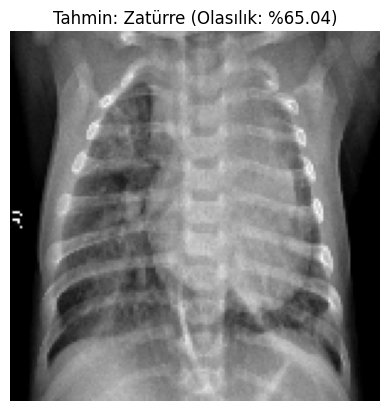

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Test klasöründen rastgele bir resim yolu seçelim

test_image_path = '/content/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# Resmi yükleyip modele uygun boyuta getirelim
test_image = image.load_img(test_image_path, target_size=(150, 150))
test_image_array = image.img_to_array(test_image)
test_image_array = np.expand_dims(test_image_array, axis=0)
test_image_array /= 255.0

# Tahmin yapalım
result = model.predict(test_image_array)

# Sonucu ekrana yazdıralım
plt.imshow(test_image)
if result[0][0] > 0.5:
    prediction = f'Zatürre (Olasılık: %{result[0][0]*100:.2f})'
else:
    prediction = f'Sağlıklı (Olasılık: %{(1-result[0][0])*100:.2f})'

plt.title(f'Tahmin: {prediction}')
plt.axis('off')
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Katman 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(2, 2))

# Katman 2 - Filtre sayısını 64'e çıkardık
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Katman 3 - 128 filtre ekleyerek detayları arttırdık
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Katman 4 - 128 filtre daha
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())

# Dropout: Bazı nöronları rastgele kapatarak modelin 'ezberlemesini' (overfitting) önler
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(
    training_set,
    epochs=20, # 10'dan 20'ye çıkardık
    validation_data=test_set
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 535ms/step - accuracy: 0.8246 - loss: 0.4112 - val_accuracy: 0.7772 - val_loss: 0.5080
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 517ms/step - accuracy: 0.9043 - loss: 0.2408 - val_accuracy: 0.7564 - val_loss: 0.5907
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 524ms/step - accuracy: 0.9187 - loss: 0.2098 - val_accuracy: 0.8574 - val_loss: 0.3755
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 515ms/step - accuracy: 0.9245 - loss: 0.1932 - val_accuracy: 0.8974 - val_loss: 0.3396
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 522ms/step - accuracy: 0.9298 - loss: 0.1768 - val_accuracy: 0.8958 - val_loss: 0.3868
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 520ms/step - accuracy: 0.9379 - loss: 0.1633 - val_accuracy: 0.8718 - val_loss: 0.4929
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 519ms/step - accuracy: 0.9396 - loss: 0.1610 - val_accuracy: 0.8814 - val_loss: 0.3872
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 522ms/step - accuracy: 0.9421 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step


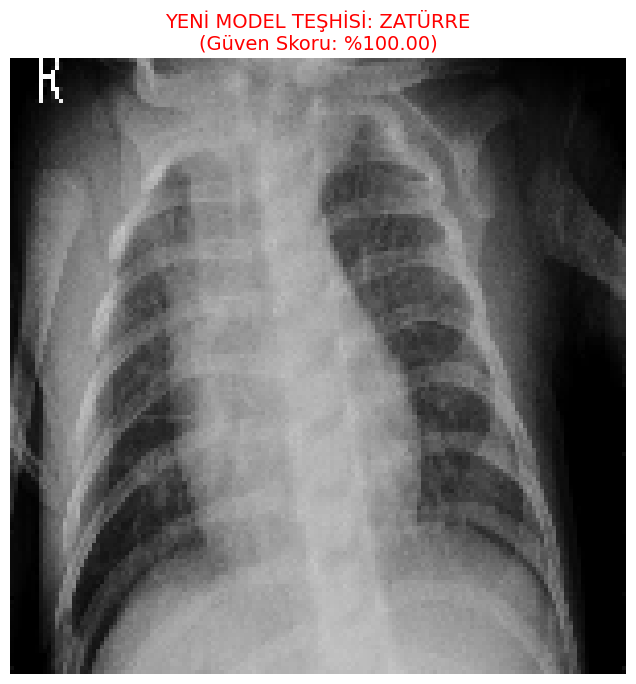

In [15]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Test klasöründen rastgele bir resim seçelim
test_pne_dir = '/content/chest_xray/test/PNEUMONIA/'
test_files = [f for f in os.listdir(test_pne_dir) if f.endswith(('.jpeg', '.jpg'))]
img_path = os.path.join(test_pne_dir, test_files[5]) # Farklı bir resim için indeksi değiştirebilirsin

# Resmi hazırla
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Tahmin yap
prediction = model.predict(img_array)

# Görselleştir
plt.figure(figsize=(8, 8))
plt.imshow(img)
if prediction[0][0] > 0.5:
    sonuc = f"YENİ MODEL TEŞHİSİ: ZATÜRRE\n(Güven Skoru: %{prediction[0][0]*100:.2f})"
else:
    sonuc = f"YENİ MODEL TEŞHİSİ: SAĞLIKLI\n(Güven Skoru: %{(1-prediction[0][0])*100:.2f})"

plt.title(sonuc, fontsize=14, color='red' if prediction[0][0] > 0.5 else 'green')
plt.axis('off')
plt.show()

In [16]:
model.save('en_iyi_zaturre_modelim.h5')
from google.colab import files
files.download('en_iyi_zaturre_modelim.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


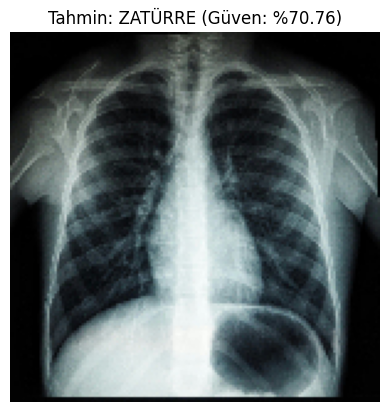

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Buraya yüklediğin resmin tam adı
kullanici_resmi = 'test_resmi.jpg'

# 2. Resmi yükle ve modelin eğitim boyutuna (150x150) getir
img = image.load_img(kullanici_resmi, target_size=(150, 150))

# 3. Resmi diziye (array) çevir ve normalize et
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

# 4. Tahmin yap
tahmin_skoru = model.predict(img_tensor)

# 5. Görselleştirme ve Sonuç
plt.imshow(img)
plt.axis('off')

if tahmin_skoru[0][0] > 0.5:
    plt.title(f"Tahmin: ZATÜRRE (Güven: %{tahmin_skoru[0][0]*100:.2f})")
else:
    plt.title(f"Tahmin: SAĞLIKLI (Güven: %{(1-tahmin_skoru[0][0])*100:.2f})")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


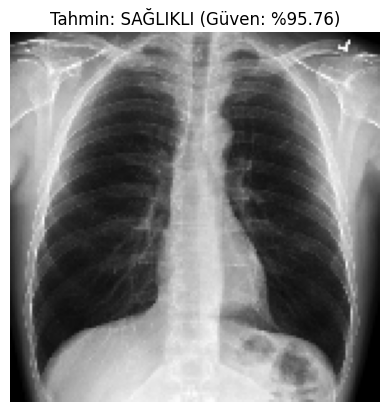

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Buraya yüklediğin resmin tam adı
kullanici_resmi = 'test_resminorm.jpg'

# 2. Resmi yükle ve modelin eğitim boyutuna (150x150) getir
img = image.load_img(kullanici_resmi, target_size=(150, 150))

# 3. Resmi diziye (array) çevir ve normalize et
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

# 4. Tahmin yap
tahmin_skoru = model.predict(img_tensor)

# 5. Görselleştirme ve Sonuç
plt.imshow(img)
plt.axis('off')

if tahmin_skoru[0][0] > 0.5:
    plt.title(f"Tahmin: ZATÜRRE (Güven: %{tahmin_skoru[0][0]*100:.2f})")
else:
    plt.title(f"Tahmin: SAĞLIKLI (Güven: %{(1-tahmin_skoru[0][0])*100:.2f})")

plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Hazır mimariyi alalım (Üst katmanlarını biz ekleyeceğiz)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Ana yapıyı donduruyoruz, sadece bizim eklediklerimiz öğrenecek

# 2. Yeni modelimizi kuralım
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Eğitimi başlatalım (20 tur yeterli olacaktır, çok hızlı öğrenecek)
history = model.fit(training_set, epochs=20, validation_data=test_set)

/tmp/ipykernel_756/2468433782.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 622ms/step - accuracy: 0.8675 - loss: 0.3075 - val_accuracy: 0.8429 - val_loss: 0.3639
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 510ms/step - accuracy: 0.9214 - loss: 0.1907 - val_accuracy: 0.8686 - val_loss: 0.3096
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 517ms/step - accuracy: 0.9312 - loss: 0.1622 - val_accuracy: 0.8510 - val_loss: 0.3701
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.9302 - loss: 0.1768 - val_accuracy: 0.8702 - val_loss: 0.3102
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 518ms/step - accuracy: 0.9398 - loss: 0.1468 - val_accuracy: 0.8846 - val_loss: 0.2958
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 506ms/step - accuracy: 0.9423 - loss: 0.1478 - val_accuracy: 0.8574 - val_loss: 0.3799
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 510ms/step - accuracy: 0.9434 - loss: 0.1459 - val_accuracy: 0.8654 - val_loss: 0.3598
Epoch 8/20
163/163 ━━━━━━━━━━━━━━

In [21]:
!pip install -q gradio

import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

def zaturre_tahmin_et(img):
    # Gelen resmi modelin istediği formata getir (150x150)
    import cv2
    img_resized = cv2.resize(img, (150, 150))
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    tahmin = model.predict(img_array)[0][0]

    if tahmin > 0.5:
        return f"Sonuç: ZATÜRRE (Güven: %{tahmin*100:.2f})"
    else:
        return f"Sonuç: SAĞLIKLI (Güven: %{(1-tahmin)*100:.2f})"

# Arayüzü tasarla - 'shape' argümanını sildik, yerine resmi içeride boyutlandırıyoruz
arayuz = gr.Interface(
    fn=zaturre_tahmin_et,
    inputs=gr.Image(), # Sadece gr.Image() yazdık
    outputs="text",
    title="Biyomedikal AI: Zatürre Tespit Sistemi",
    description="Analiz için bir göğüs röntgeni yükleyin."
)

arayuz.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://42cef5aed83ce8d548.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import gradio as gr
import cv2
import numpy as np

# AŞAMA 1: Devler Üstünde Yükselmek (Transfer Learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

final_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(training_set, epochs=10, validation_data=test_set) # Zaten akıllı olduğu için 10 tur yeterli

# AŞAMA 2: Gelişmiş Tahmin Fonksiyonu
def tahmin_motoru(img):
    img_resized = cv2.resize(img, (150, 150))
    img_array = img_resized.reshape((-1, 150, 150, 3)) / 255.0
    olasilik = float(final_model.predict(img_array)[0][0])

    return {"Zatürre": olasilik, "Sağlıklı": 1 - olasilik}

# AŞAMA 3: Profesyonel Arayüz
demo = gr.Interface(
    fn=tahmin_motoru,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=2), # En yüksek 2 olasılığı bar şeklinde gösterir
    title="🔬 Biyomedikal Yapay Zeka: Radyolojik Analiz Sistemi",
    description="Derin öğrenme tabanlı bu sistem, göğüs röntgenlerini analiz ederek patolojik bulguları tespit eder.",
    theme="soft"
)

demo.launch(share=True)

/tmp/ipykernel_756/2545439371.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 575ms/step - accuracy: 0.9026 - loss: 0.2356 - val_accuracy: 0.8830 - val_loss: 0.2998
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 537ms/step - accuracy: 0.9440 - loss: 0.1439 - val_accuracy: 0.8942 - val_loss: 0.2655
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 527ms/step - accuracy: 0.9480 - loss: 0.1389 - val_accuracy: 0.8333 - val_loss: 0.5395
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 520ms/step - accuracy: 0.9471 - loss: 0.1358 - val_accuracy: 0.8397 - val_loss: 0.5252
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 521ms/step - accuracy: 0.9490 - loss: 0.1272 - val_accuracy: 0.8766 - val_loss: 0.3330
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 532ms/step - accuracy: 0.9532 - loss: 0.1192 - val_accuracy: 0.8718 - val_loss: 0.3643
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 521ms/step - accuracy: 0.9538 - loss: 0.1138 - val_accuracy: 0.8750 - val_loss: 0.3719
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 530ms/step - accuracy: 0.9525 - loss: 